In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:

# LogisticRegression()

In [51]:
import pandas as pd

df = pd.read_csv('../datasets/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [55]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [56]:
df['High_Sales'] = (df['Total Amount'] > 500).astype(int)

In [57]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
High_Sales          0
dtype: int64

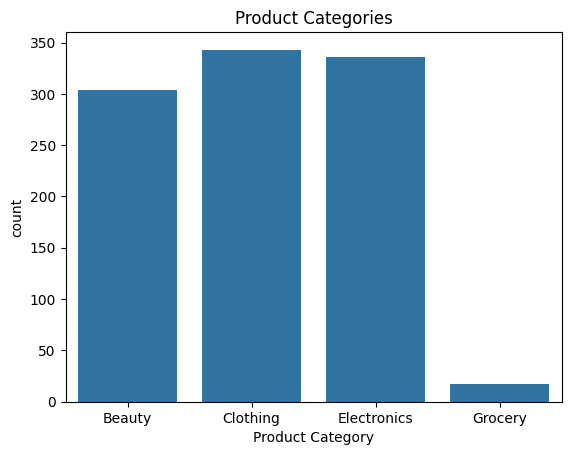

In [58]:
sns.countplot(x='Product Category', data=df)

plt.title('Product Categories')
plt.show()

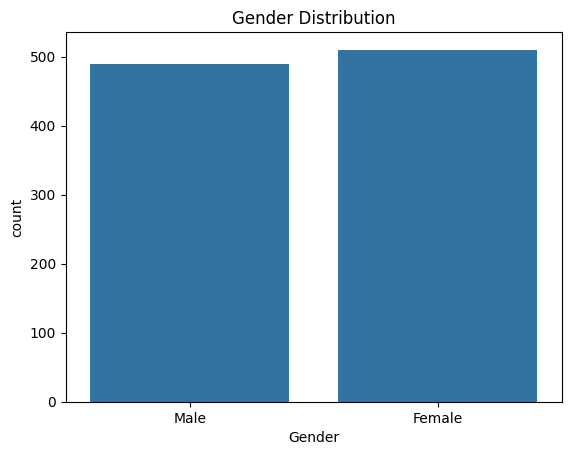

In [59]:
sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.show()

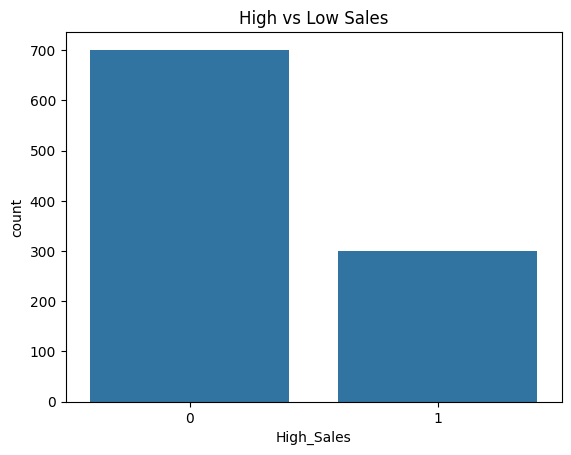

In [60]:
sns.countplot(x='High_Sales', data=df)

plt.title('High vs Low Sales')
plt.show()

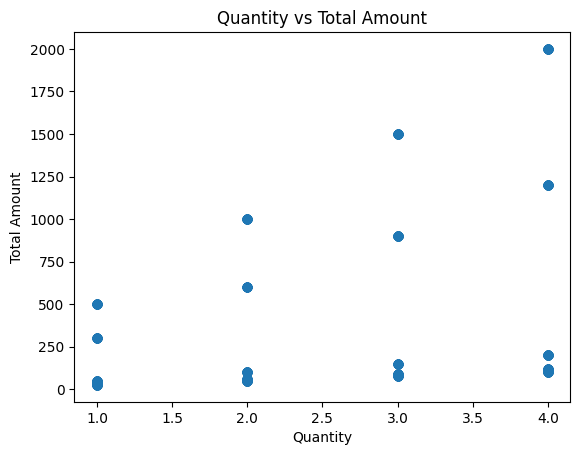

In [61]:
plt.scatter(df['Quantity'], df['Total Amount'])

plt.xlabel('Quantity')
plt.ylabel('Total Amount')

plt.title('Quantity vs Total Amount')

plt.show()

In [62]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_category = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])

df['Product Category'] = le_category.fit_transform(df['Product Category'])

In [63]:
X = df[['Quantity', 'Price per Unit', 'Age', 'Gender', 'Product Category']]

y = df['High_Sales']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [66]:
prediction = model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy * 100)

Accuracy: 94.5


In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[133   6]
 [  5  56]]


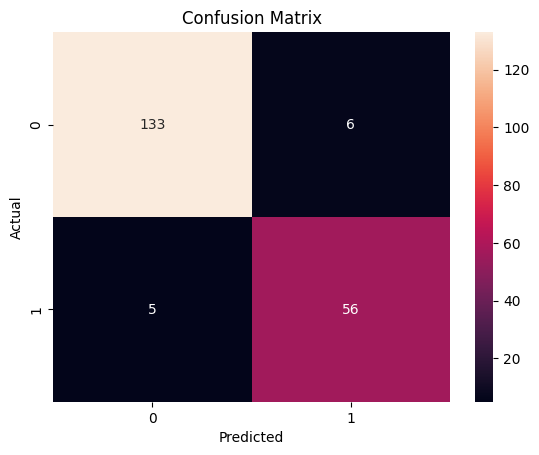

In [69]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       139
           1       0.90      0.92      0.91        61

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.94       200
weighted avg       0.95      0.94      0.95       200



In [71]:
new_data = pd.DataFrame({
    'Quantity': [3],
    'Price per Unit': [500],
    'Age': [25],
    'Gender': [1],
    'Product Category': [2]
})

result = model.predict(new_data)

print(result)

[1]


In [72]:
import joblib

joblib.dump(model, '../ml_models/logistic_sales_model.pkl')

['../ml_models/logistic_sales_model.pkl']

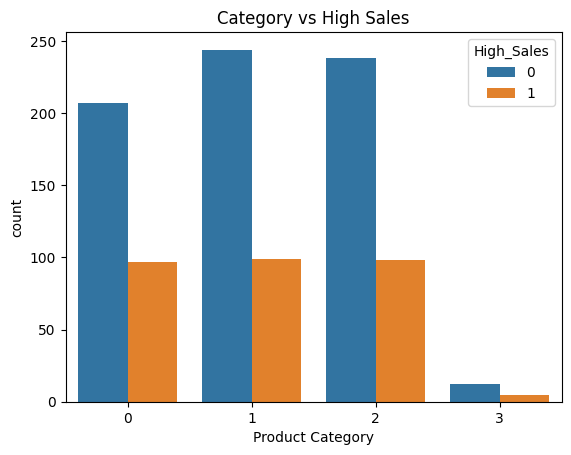

In [73]:
sns.countplot(x='Product Category', hue='High_Sales', data=df)

plt.title("Category vs High Sales")
plt.show()